In [ ]:
import os
import cv2 # For video and frame processing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2, ResNet50V2

print("TensorFlow Version:", tf.__version__)
print("OpenCV Version:", cv2.__version__)


TensorFlow Version: 2.19.0
OpenCV Version: 4.13.0


In [ ]:
import kagglehub
import os
from glob import glob

# Download latest version dynamically
print("Downloading dataset from Kaggle...")
DATA_DIR = kagglehub.dataset_download("phylake1337/fire-dataset")
print("Path to dataset files:", DATA_DIR)

print(f"\n--- Inspecting downloaded dataset directory: {DATA_DIR} ---")
!ls -F "{DATA_DIR}"

# Ensure the paths match the Kaggle dataset structure
# The dataset is nested under 'fire_dataset' directory within the downloaded DATA_DIR
NESTED_DATA_DIR = os.path.join(DATA_DIR, 'fire_dataset')
FIRE_DIR = os.path.join(NESTED_DATA_DIR, 'fire_images')
NON_FIRE_DIR = os.path.join(NESTED_DATA_DIR, 'non_fire_images')

print(f"\n--- Checking FIRE_DIR: {FIRE_DIR} ---")
if os.path.exists(FIRE_DIR):
    print("FIRE_DIR exists. Contents (first 5):")
    !ls -F "{FIRE_DIR}" | head -n 5
else:
    print("FIRE_DIR does NOT exist.")

print(f"\n--- Checking NON_FIRE_DIR: {NON_FIRE_DIR} ---")
if os.path.exists(NON_FIRE_DIR):
    print("NON_FIRE_DIR exists. Contents (first 5):")
    !ls -F "{NON_FIRE_DIR}" | head -n 5
else:
    print("NON_FIRE_DIR does NOT exist.")

# Count the images to verify successful download
fire_images = glob(os.path.join(FIRE_DIR, '*.*'))
non_fire_images = glob(os.path.join(NON_FIRE_DIR, '*.*'))

print(f"\n✅ Total Fire Images Loaded: {len(fire_images)}")
print(f"✅ Total Non-Fire Images Loaded: {len(non_fire_images)}")

Using Colab cache for faster access to the 'fire-dataset' dataset.
Path to dataset files: /kaggle/input/fire-dataset

--- Inspecting downloaded dataset directory: /kaggle/input/fire-dataset ---
fire_dataset/

--- Checking FIRE_DIR: /kaggle/input/fire-dataset/fire_dataset/fire_images ---
FIRE_DIR exists. Contents (first 5):
fire.100.png
fire.101.png
fire.102.png
fire.103.png
fire.104.png

--- Checking NON_FIRE_DIR: /kaggle/input/fire-dataset/fire_dataset/non_fire_images ---
NON_FIRE_DIR exists. Contents (first 5):
non_fire.100.png
non_fire.101.png
non_fire.102.png
non_fire.103.png
non_fire.104.png

✅ Total Fire Images Loaded: 755
✅ Total Non-Fire Images Loaded: 244


/tmp/ipykernel_1775/61749439.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=counts, palette=['#ff4500', '#2ca02c'])


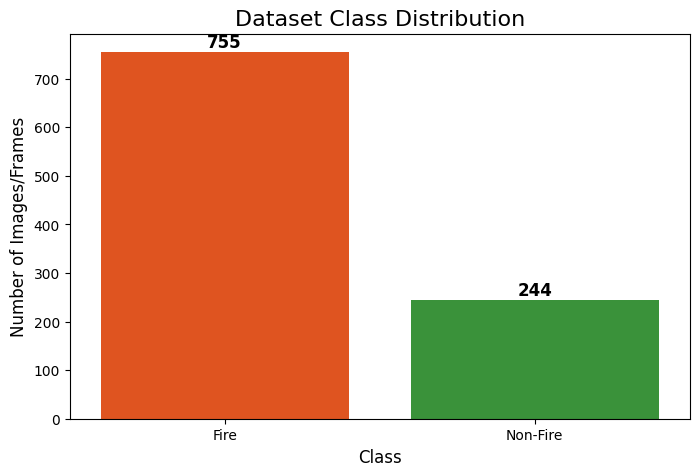

In [ ]:
categories = ['Fire', 'Non-Fire']
counts = [len(fire_images), len(non_fire_images)]

plt.figure(figsize=(8, 5))
sns.barplot(x=categories, y=counts, palette=['#ff4500', '#2ca02c'])
plt.title('Dataset Class Distribution', fontsize=16)
plt.ylabel('Number of Images/Frames', fontsize=12)
plt.xlabel('Class', fontsize=12)

# Add text labels on the bars
for i, count in enumerate(counts):
    plt.text(i, count + 10, str(count), ha='center', fontsize=12, fontweight='bold')

plt.show()


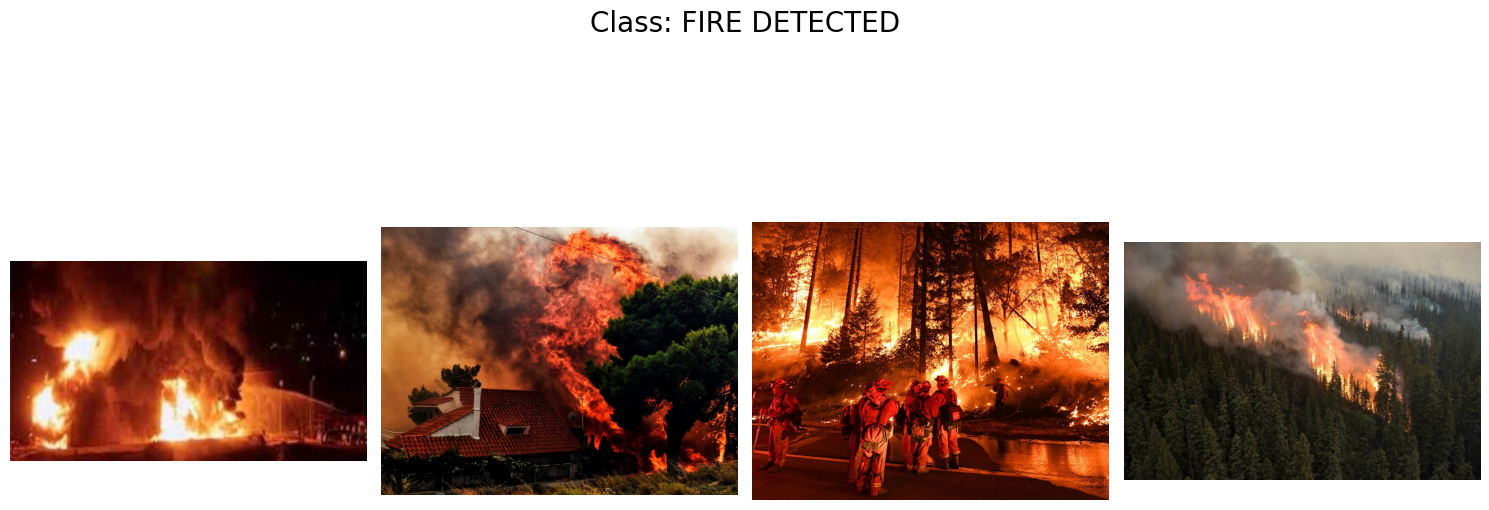

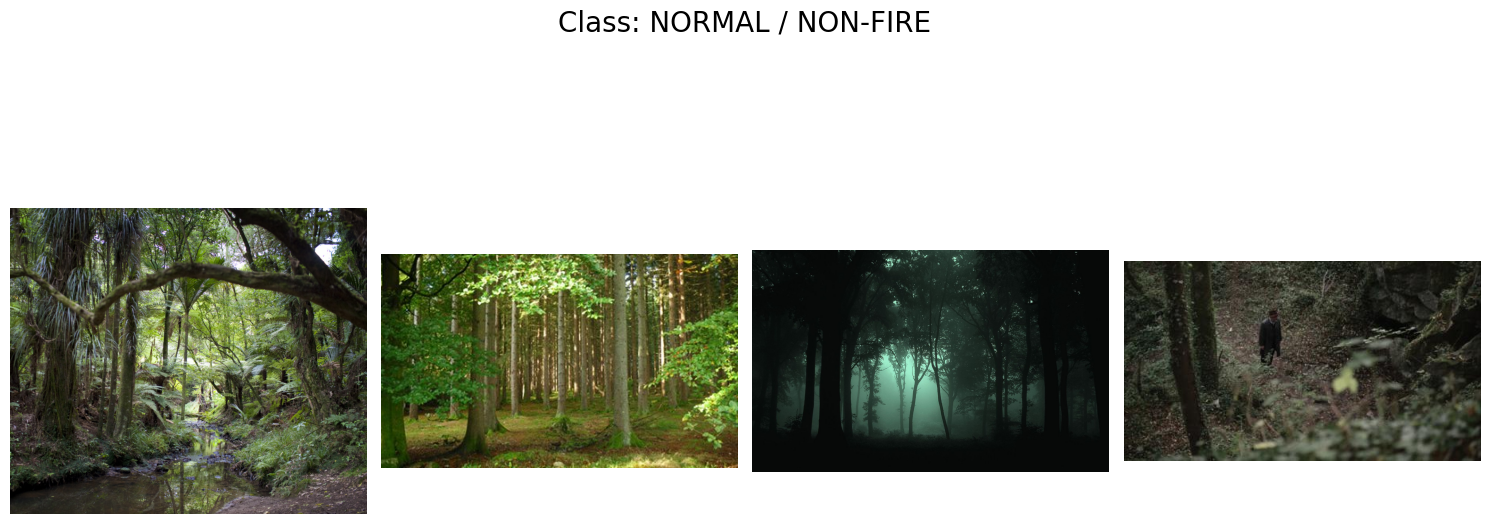

In [ ]:
import random

def plot_samples(image_paths, title, rows=2, cols=4):
    plt.figure(figsize=(15, 6))
    plt.suptitle(title, fontsize=20, y=1.05)

    # Pick random samples
    samples = random.sample(image_paths, rows * cols)

    for i, img_path in enumerate(samples):
        img = load_img(img_path) # Reads image in RGB format
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Show Fire Examples
plot_samples(fire_images, "Class: FIRE DETECTED", rows=1, cols=4)

# Show Non-Fire Examples
plot_samples(non_fire_images, "Class: NORMAL / NON-FIRE", rows=1, cols=4)


In [ ]:
import cv2

def remove_corrupted_images(folder_path):
    removed = 0
    for img_path in glob(os.path.join(folder_path, '*.*')):
        try:
            # Try to read the image
            img = cv2.imread(img_path)
            if img is None:
                os.remove(img_path)
                removed += 1
        except Exception as e:
            os.remove(img_path)
            removed += 1
    return removed

print("Checking for corrupted files...")
bad_fire = remove_corrupted_images(FIRE_DIR)
bad_non_fire = remove_corrupted_images(NON_FIRE_DIR)

print(f"Removed {bad_fire} corrupted fire images.")
print(f"Removed {bad_non_fire} corrupted non-fire images.")


Checking for corrupted files...
Removed 0 corrupted fire images.
Removed 0 corrupted non-fire images.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 1. Training Generator WITH Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

print(f"Loading Training Data from {NESTED_DATA_DIR}:")
train_generator = train_datagen.flow_from_directory(
    NESTED_DATA_DIR, # <-- USING YOUR CORRECTED PATH
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

print("\nLoading Validation Data:")
val_generator = train_datagen.flow_from_directory(
    NESTED_DATA_DIR, # <-- USING YOUR CORRECTED PATH
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# Address Class Imbalance with weights
total_samples = len(fire_images) + len(non_fire_images)
weight_for_fire = (1 / len(fire_images)) * (total_samples / 2.0)
weight_for_non_fire = (1 / len(non_fire_images)) * (total_samples / 2.0)

class_weights = {
    train_generator.class_indices['fire_images']: weight_for_fire,
    train_generator.class_indices['non_fire_images']: weight_for_non_fire
}


Loading Training Data from /kaggle/input/fire-dataset/fire_dataset:
Found 800 images belonging to 2 classes.

Loading Validation Data:
Found 199 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build Baseline Model
model_1 = Sequential([
    # Layer 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),

    # Layer 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Layer 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Fully Connected Output
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Prevents overfitting by randomly dropping 50% of connections
    Dense(1, activation='sigmoid') # Sigmoid gives a probability between 0 and 1
])

# Compile the model
model_1.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

model_1.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 1. Ask Keras what classes it actually found!
keras_classes = list(train_generator.class_indices.keys())
print(f"Keras successfully found these classes: {keras_classes}")

if len(keras_classes) < 2:
    raise ValueError("⚠️ ERROR: Keras only found 1 class! Please ensure the previous cell uses 'NESTED_DATA_DIR' in flow_from_directory.")

# 2. Automatically identify which class is fire and which is non-fire
# We assume the non-fire class will have the word 'non' in its folder name
fire_class_name = [c for c in keras_classes if 'non' not in c.lower()][0]
non_fire_class_name = [c for c in keras_classes if 'non' in c.lower()][0]

# 3. Calculate weights automatically
total_samples = train_generator.samples + val_generator.samples # Gets the exact number of images loaded by Keras

# To find exactly how many images exist per class in the generator
fire_samples = len(glob(os.path.join(NESTED_DATA_DIR, fire_class_name, '*.*')))
non_fire_samples = len(glob(os.path.join(NESTED_DATA_DIR, non_fire_class_name, '*.*')))

weight_for_fire = (1 / fire_samples) * (total_samples / 2.0)
weight_for_non_fire = (1 / non_fire_samples) * (total_samples / 2.0)

# 4. Safely map to the correct dictionary indices
class_weights = {
    train_generator.class_indices[fire_class_name]: weight_for_fire,
    train_generator.class_indices[non_fire_class_name]: weight_for_non_fire
}

print(f"\n✅ Applied Class Weights successfully:\n{fire_class_name}: {weight_for_fire}\n{non_fire_class_name}: {weight_for_non_fire}\n")

# 5. Train Model 1
history_1 = model_1.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights
)


Keras successfully found these classes: ['fire_images', 'non_fire_images']

✅ Applied Class Weights successfully:
fire_images: 0.66158940397351
non_fire_images: 2.0471311475409837

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.8500 - loss: 0.3818 - val_accuracy: 0.8945 - val_loss: 0.2197
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9287 - loss: 0.2116 - val_accuracy: 0.9095 - val_loss: 0.2008
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9463 - loss: 0.1413 - val_accuracy: 0.8995 - val_loss: 0.2358
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9438 - loss: 0.1600 - val_accuracy: 0.9447 - val_loss: 0.1613
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9600 - loss: 0.1111 - val_accuracy: 0.9497 - val_loss: 0.1610
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9575 - loss: 0.0979 - val_accuracy: 0.9296 - val_loss: 0.1569
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0

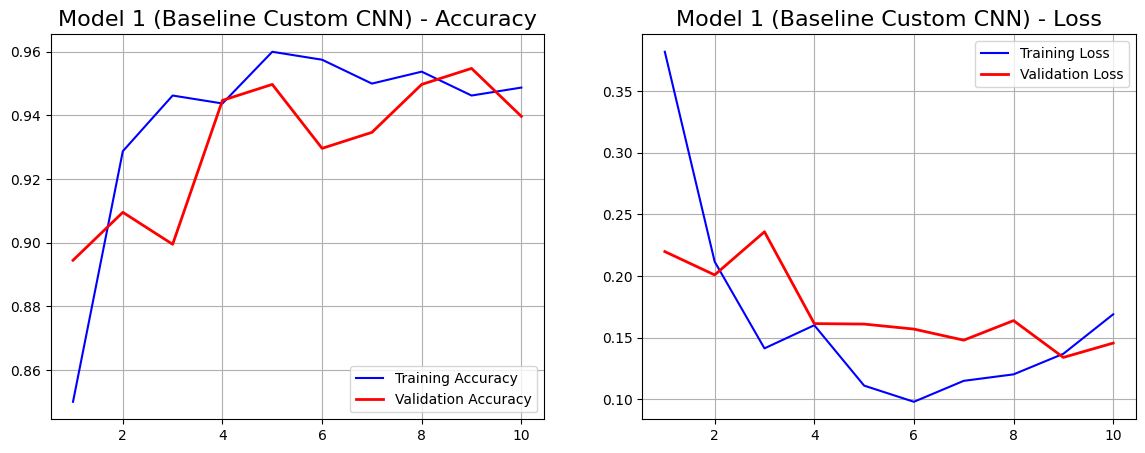

In [ ]:
def plot_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
    plt.title(f'{model_name} - Accuracy', fontsize=16)
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
    plt.title(f'{model_name} - Loss', fontsize=16)
    plt.legend()
    plt.grid(True)

    plt.show()

# Run the plotter for the trained baseline model
plot_history(history_1, "Model 1 (Baseline Custom CNN)")


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

# 1. Load the pre-trained MobileNetV2 (excluding its top classification layers)
base_model_mobilenet = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# 2. FREEZE the base layers so we don't accidentally destroy the pre-trained knowledge
base_model_mobilenet.trainable = False

# 3. Build our new Classification Head on top of it
model_2 = Sequential([
    base_model_mobilenet,
    GlobalAveragePooling2D(), # Condenses the output of the convolutional layers
    Dense(64, activation='relu'),
    Dropout(0.3),             # Prevents overfitting
    Dense(1, activation='sigmoid') # Final Fire vs Non-Fire prediction
])

# 4. Compile it
model_2.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

print("MobileNetV2 Architecture successfully loaded!")
model_2.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 Architecture successfully loaded!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training MobileNetV2...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.8800 - loss: 0.2774 - val_accuracy: 0.9196 - val_loss: 0.2032
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9575 - loss: 0.1095 - val_accuracy: 0.9296 - val_loss: 0.1641
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9725 - loss: 0.1003 - val_accuracy: 0.9548 - val_loss: 0.1448
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9625 - loss: 0.0840 - val_accuracy: 0.9497 - val_loss: 0.1167
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9762 - loss: 0.0687 - val_accuracy: 0.9548 - val_loss: 0.1409
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9825 - loss: 0.0542 - val_accuracy: 0.9447 - val_loss: 0.1439
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9712 - loss: 0.0607 - val_accuracy: 0.9296 - val_loss: 0.1917
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9712 - loss: 0.0754 - val_accu

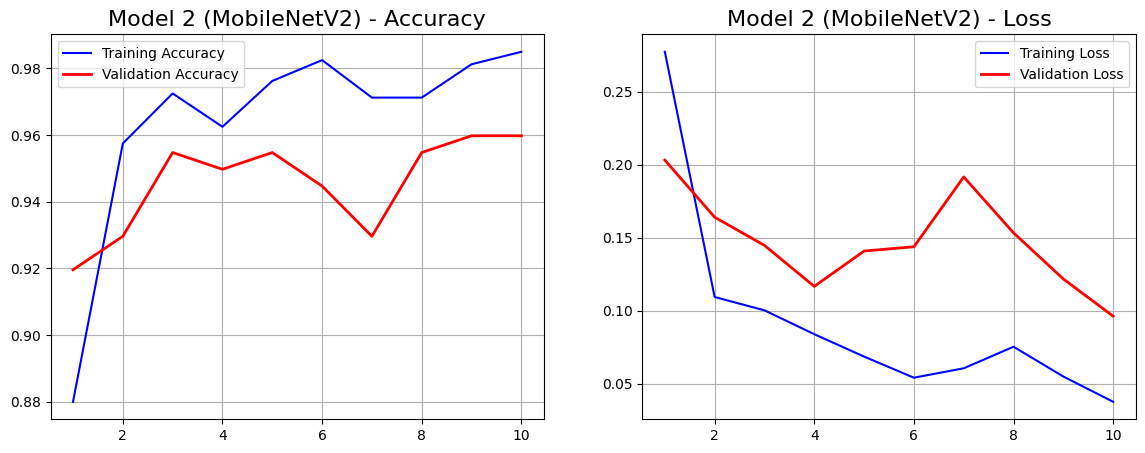

In [ ]:
print("Training MobileNetV2...")

history_2 = model_2.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights # We reuse the balance check from earlier!
)

# Plot the beautiful learning curves
plot_history(history_2, "Model 2 (MobileNetV2)")


In [ ]:
from tensorflow.keras.applications import ResNet50V2

# 1. Load the completely pre-trained ResNet50V2 model
base_model_resnet = ResNet50V2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# 2. FREEZE the base layers
base_model_resnet.trainable = False

# 3. Build our new Classification Head on top
model_3 = Sequential([
    base_model_resnet,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4), # Slightly higher dropout for deeper networks
    Dense(1, activation='sigmoid') # Final Fire vs Non-Fire prediction
])

model_3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("ResNet50V2 Architecture successfully loaded!")
model_3.summary()


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
ResNet50V2 Architecture successfully loaded!


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,827,201 (90.89 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Training ResNet50V2...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.8913 - loss: 0.2923 - val_accuracy: 0.9347 - val_loss: 0.1598
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9638 - loss: 0.1208 - val_accuracy: 0.9246 - val_loss: 0.2062
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9700 - loss: 0.0795 - val_accuracy: 0.9196 - val_loss: 0.2745
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9712 - loss: 0.0756 - val_accuracy: 0.9045 - val_loss: 0.3084
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9775 - loss: 0.0767 - val_accuracy: 0.9447 - val_loss: 0.1620
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9812 - loss: 0.0451 - val_accuracy: 0.9095 - val_loss: 0.2781
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9825 - loss: 0.0502 - val_accuracy: 0.9347 - val_loss: 0.1969
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9887 - loss: 0.0305 - val_accur

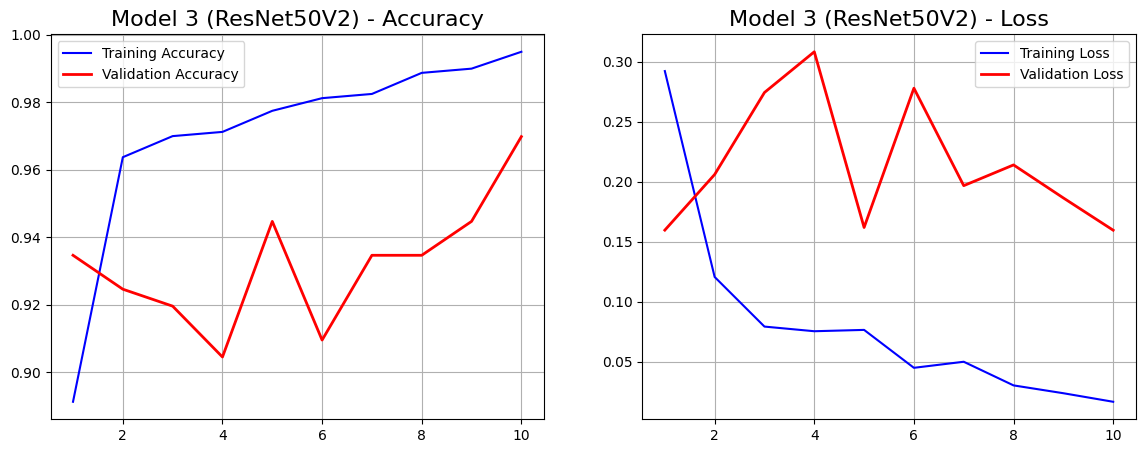

In [ ]:
print("Training ResNet50V2...")

history_3 = model_3.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights # Uses the dynamic class weights from earlier
)

# Evaluate Learning curves
plot_history(history_3, "Model 3 (ResNet50V2)")


/tmp/ipykernel_1775/3587303004.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette="magma")


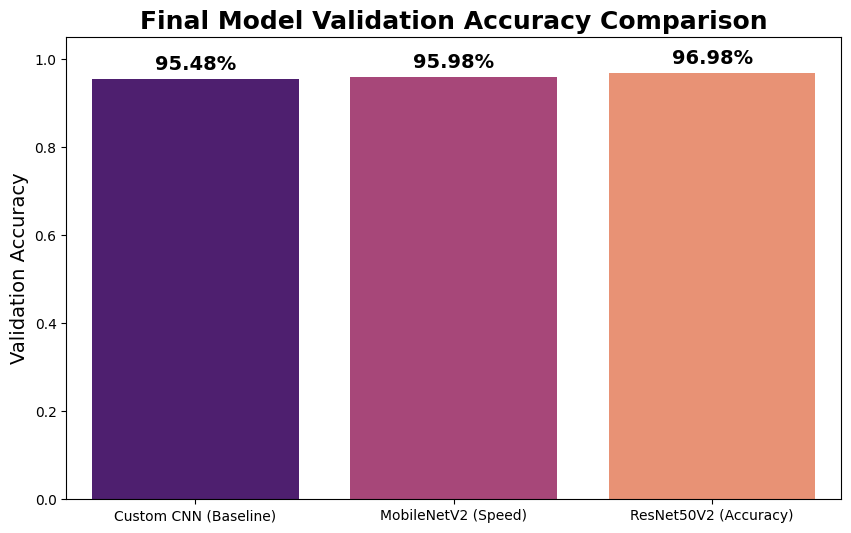


Saving the Best Model physically to the Colab disk...
✅ Saved as 'best_fire_detection_model.h5'


In [ ]:
import seaborn as sns

# Extract the highest validation accuracy achieved by each model
val_acc_1 = max(history_1.history['val_accuracy'])
val_acc_2 = max(history_2.history['val_accuracy'])
val_acc_3 = max(history_3.history['val_accuracy'])

models = ['Custom CNN (Baseline)', 'MobileNetV2 (Speed)', 'ResNet50V2 (Accuracy)']
accuracies = [val_acc_1, val_acc_2, val_acc_3]

# Create a beautiful Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette="magma")
plt.title("Final Model Validation Accuracy Comparison", fontsize=18, fontweight='bold')
plt.ylabel("Validation Accuracy", fontsize=14)
plt.ylim(0, 1.05) # Cap Y-axis slightly above 100% for readability

# Add text percentage labels mathematically
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2%}", ha='center', fontsize=14, fontweight='bold')

plt.show()

# Save the best model! (Assuming ResNet is your best, though you can swap model_3 for model_2 if MobileNet won)
print("\nSaving the Best Model physically to the Colab disk...")
model_3.save("best_fire_detection_model.h5")
print("✅ Saved as 'best_fire_detection_model.h5'")


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from google.colab.patches import cv2_imshow # Special display function for Colab

# 1. Load the Saved Model (This proves the script works completely independently of training)
print("Loading Model...")
final_model = load_model("best_fire_detection_model.h5")

# Check Keras class indices to know whether 0 is fire or 1 is fire!
# Since Keras alphabetizes folders automatically: fire_images = 0, non_fire_images = 1
FIRE_INDEX = 0
NON_FIRE_INDEX = 1

def process_video_frame(frame, model):
    """
    Takes 1 frame of a video, prepares it exactly like our training images,
    and returns the frame heavily stamped with the model's prediction.
    """
    # Resize and scale to match Training settings
    img = cv2.resize(frame, (224, 224))
    img = img / 255.0  # Normalize
    img = np.expand_dims(img, axis=0) # Add a 'Batch' dimension so Keras accepts it

    # Predict
    prediction_prob = model.predict(img, verbose=0)[0][0] # verbose=0 stops printing logs every single frame

    # Keras Sigmoid logic: Since "fire_images" is index 0, probabilities close to 0 mean FIRE!
    # Probabilities close to 1 mean NON_FIRE!
    if prediction_prob < 0.5:
        label = "WARNING: FIRE DETECTED!"
        color = (0, 0, 255) # Red text BGR
    else:
        label = "Normal (No Fire)"
        color = (0, 255, 0) # Green text BGR

    # Stamp the text physically onto the frame
    cv2.putText(frame, label, (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3, cv2.LINE_AA)
    return frame

print("✅ Video processing script is fully ready!")

# --- HOW TO TEST THIS IN COLAB ---
# 1. Upload a random 5-second fire video to Colab via the folder icon (name it 'fire_test.mp4').
# 2. Uncomment the code below to run it!

"""
# Open the test video file
cap = cv2.VideoCapture('fire_test.mp4')

frame_count = 0
while cap.isOpened() and frame_count < 150: # Will process up to 150 frames (5 seconds of video)
    ret, frame = cap.read()
    if not ret:
        break # Video ended

    # Send frame to our ML model
    processed_frame = process_video_frame(frame, final_model)

    # Display the processed frame right inside Colab
    cv2_imshow(processed_frame)

    frame_count += 1

cap.release()
print("Video Processing Complete.")
"""


Loading Model...


✅ Video processing script is fully ready!


'\n# Open the test video file\ncap = cv2.VideoCapture(\'fire_test.mp4\')\n\nframe_count = 0\nwhile cap.isOpened() and frame_count < 150: # Will process up to 150 frames (5 seconds of video)\n    ret, frame = cap.read()\n    if not ret:\n        break # Video ended\n    \n    # Send frame to our ML model\n    processed_frame = process_video_frame(frame, final_model)\n    \n    # Display the processed frame right inside Colab\n    cv2_imshow(processed_frame) \n    \n    frame_count += 1\n\ncap.release()\nprint("Video Processing Complete.")\n'

In [ ]:
import os

# Define the name of your final video model
model_save_path = "best_video_fire_model.h5"

# Save the entire model (architecture, weights, and compiler state)
model_2.save(model_save_path) # Assuming MobileNetV2 (model_2) is your best video model

# Check the file size to prove it saved correctly
file_size_mb = os.path.getsize(model_save_path) / (1024 * 1024)
print(f"✅ Deep Learning Model successfully saved as: {model_save_path}")
print(f"📊 File Size: {file_size_mb:.2f} MB")


✅ Deep Learning Model successfully saved as: best_video_fire_model.h5
📊 File Size: 9.91 MB


In [ ]:
import pickle
import json

# 1. Extract the architecture (JSON string) and weights (Numpy Arrays)
model_architecture = model_2.to_json()
model_weights = model_2.get_weights()

# 2. Package them entirely into a native Python dictionary
model_package = {
    'architecture': model_architecture,
    'weights': model_weights
}

# 3. Save as .pkl safely!
with open('best_video_fire_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("✅ Master Model safely packaged into a .pkl file!")


✅ Master Model safely packaged into a .pkl file!


In [ ]:
import os
import shutil
from google.colab import drive

# 1. Mount your Google Drive (A popup will ask for your Google permission)
print("Mounting Google Drive...\n")
drive.mount('/content/drive')

# 2. Define exactly where you want to save it inside your Drive
# This saves it directly to the root of your Google Drive
DRIVE_SAVE_PATH = '/content/drive/MyDrive/best_video_fire_model.pkl'

# The file we created earlier in Colab's temporary storage
LOCAL_MODEL_PATH = 'best_video_fire_model.pkl'

# 3. Securely copy the file to Google Drive
if os.path.exists(LOCAL_MODEL_PATH):
    shutil.copy(LOCAL_MODEL_PATH, DRIVE_SAVE_PATH)
    print(f"\n✅ SUCCESS: The best model is permanently saved to your Drive at:\n -> {DRIVE_SAVE_PATH}")
else:
    print(f"\n❌ ERROR: '{LOCAL_MODEL_PATH}' was not found. Did you run the pickling cell?")


Mounting Google Drive...

Mounted at /content/drive

✅ SUCCESS: The best model is permanently saved to your Drive at:
 -> /content/drive/MyDrive/best_video_fire_model.pkl


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


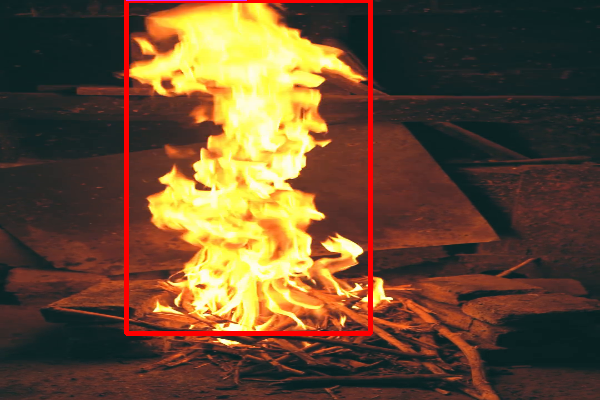

In [ ]:
import pickle
import cv2
import numpy as np
import time
from tensorflow.keras.models import model_from_json
from IPython.display import clear_output
from google.colab.patches import cv2_imshow

# ==========================================
# 1. LOAD THE MODEL DIRECTLY FROM GOOGLE DRIVE (NO TRAINING REQUIRED!)
# ==========================================
# Make sure your drive is mounted first: drive.mount('/content/drive')

DRIVE_SAVE_PATH = '/content/drive/MyDrive/best_video_fire_model.pkl'
print("Loading trained AI Brain from Google Drive...")

with open(DRIVE_SAVE_PATH, 'rb') as f:
    loaded_package = pickle.load(f)

loaded_model = model_from_json(loaded_package['architecture'])
loaded_model.set_weights(loaded_package['weights'])
print("✅ AI Brain loaded successfully!\n")


# ==========================================
# 2. THE YOLO-STYLE VIDEO TRACKER
# ==========================================
VIDEO_PATH = "8064377-hd_1080_1920_24fps.mp4" # Ensure this video is uploaded to Colab!

def process_and_draw_boxes(video_path, model):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Error: Cannot open '{video_path}'. Please upload it.")
        return

    print("▶️ Processing Video Stream with Intelligent Bounding Boxes...\n")
    time.sleep(2)

    frame_count = 0
    while cap.isOpened() and frame_count < 200:
        ret, frame = cap.read()
        if not ret:
            break

        frame_display = cv2.resize(frame, (600, 400))

        # Ask our loaded model if it sees fire
        img_for_model = cv2.resize(frame, (224, 224))
        img_for_model = img_for_model / 255.0
        img_for_model = np.expand_dims(img_for_model, axis=0)
        prediction_prob = model.predict(img_for_model, verbose=0)[0][0]

        if prediction_prob < 0.5: # FIRE DETECTED
            confidence = (1 - prediction_prob) * 100

            # --- OPEN CV TRACKING MAGIC ---
            hsv = cv2.cvtColor(frame_display, cv2.COLOR_BGR2HSV)
            lower_fire = np.array([10, 100, 100], dtype=np.uint8)
            upper_fire = np.array([35, 255, 255], dtype=np.uint8)
            mask = cv2.inRange(hsv, lower_fire, upper_fire)

            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for contour in contours:
                if cv2.contourArea(contour) > 800:
                    x, y, w, h = cv2.boundingRect(contour)
                    cv2.rectangle(frame_display, (x, y), (x+w, y+h), (0, 0, 255), 4)

                    text = f"fire {confidence:.0f}%"
                    cv2.rectangle(frame_display, (x, y-30), (x+120, y), (255, 51, 204), -1)
                    cv2.putText(frame_display, text, (x+5, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        else:
            cv2.putText(frame_display, "STATUS: SAFE", (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

        clear_output(wait=True)
        cv2_imshow(frame_display)
        frame_count += 1

    cap.release()

# Run the tracker!
process_and_draw_boxes(VIDEO_PATH, loaded_model)
